<a href="https://colab.research.google.com/github/hugh1704/bomun2/blob/main/20260223_bulk_RNAseq_pipeline_sl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown

file_id = "1uEBMugyi6_QMy6qfwrLohIHmcl4t8g4i"
output = "/content/Rlib.tar" # 저장 위치 및 저장할 파일 이름
gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1uEBMugyi6_QMy6qfwrLohIHmcl4t8g4i
From (redirected): https://drive.google.com/uc?id=1uEBMugyi6_QMy6qfwrLohIHmcl4t8g4i&confirm=t&uuid=4fa901a3-eb4e-4707-ba32-7d43ba0fb543
To: /content/Rlib.tar
100%|██████████| 1.64G/1.64G [00:20<00:00, 78.7MB/s]


'/content/Rlib.tar'

In [ ]:
# tar 파일 압축 해제

!tar -xf /content/Rlib.tar

In [ ]:
# R 사용환경 세팅

!pip install -q rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# R 라이브러리 path 지정
%%R
.libPaths("/content/content/drive/MyDrive/R_libs")
.libPaths()

[1] "/content/content/drive/MyDrive/R_libs"
[2] "/usr/local/lib/R/site-library"        
[3] "/usr/lib/R/site-library"              
[4] "/usr/lib/R/library"                   


In [ ]:
%%R
suppressPackageStartupMessages({
  library(gtools)
  library(readxl)
  library(DESeq2)
  library(ggplot2)
  library(ggridges)
  library(biomaRt)
  library(dplyr)
  library(limma)
  library(sva)
  library(tidyverse)
  library(gridExtra)
  library(clusterProfiler)
  library(msigdbr)
  library(enrichplot)
  library(apeglm)
  library(pheatmap)
  library(RColorBrewer)
  library(AnnotationDbi)
  library(org.Hs.eg.db)
  library(fgsea)
  library(vegan)
  library(ggrepel)
  library(EnhancedVolcano)
  library(forcats)
})

In [ ]:
import gdown

file_id = "1GlJgCCr662zx0XpHvzcmnHyrhTk6ULwF"
output = "/content/data.tar" # 저장 위치 및 저장할 파일 이름
gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1GlJgCCr662zx0XpHvzcmnHyrhTk6ULwF
To: /content/data.tar
100%|██████████| 1.51M/1.51M [00:00<00:00, 82.2MB/s]


'/content/data.tar'

In [ ]:
# tar 파일 압축 해제

!tar -xf /content/data.tar

In [ ]:
%%R
# import count matrix
count_matrix <- readRDS("/content/content/drive/MyDrive/data/count_matrix.rds")
head(count_matrix)

                V8 V9 V10 V23 V42 V44
ENSG00000290825  0  0   0   0   0   0
DDX11L1          0  0   2   0   0   0
WASH7P           9  3  13  44  17  36
MIR6859-1        4  6   0   1   4   3
MIR1302-2HG      0  0   0   0   0   0
MIR1302-2        0  0   0   0   0   0


In [ ]:
%%R
# Quality control of zero counts / low counts
smallest_group_size <- 3
keep <- rowSums(count_matrix >= 10) >= smallest_group_size
count_matrix <- count_matrix[keep, ]
head(count_matrix)

                V8  V9 V10 V23 V42 V44
WASH7P           9   3  13  44  17  36
ENSG00000269981  5   4  11  13   5  11
DDX11L17        34  12   6   0  14  16
WASH9P          76 126 115 124  54 130
ENSG00000290385 19  25  27  51  55  52
MTND1P23        13  18   8   9  36  14


In [ ]:
%%R
# import metadata
metadata <- readRDS("/content/content/drive/MyDrive/data/metadata.rds")
head(metadata)

    sex age      BMI    wt    fat % relative_BMI
V8    F  31 46.18308 128.8 45.96273         high
V9    M  44 30.26572  88.5 63.50282          low
V10   F  48 30.15768  75.0 99.86667          low
V23   M  47 30.10381  87.0 67.35632          low
V42   F  34 46.02076 133.0 25.71429         high
V44   F  54 51.79458 129.3 60.01547         high


In [ ]:
%%R
# Combine count matrix and metadata into a single object named dds
dds <- DESeqDataSetFromMatrix(countData = count_matrix,
                                            colData = metadata,
                                            design = ~ relative_BMI)
dds

class: DESeqDataSet 
dim: 20019 6 
metadata(1): version
assays(1): counts
rownames(20019): WASH7P ENSG00000269981 ... MT-CYB MT-TP
rowData names(0):
colnames(6): V8 V9 ... V42 V44
colData names(6): sex age ... fat % relative_BMI


converting counts to integer mode


using ntop=500 top features by variance


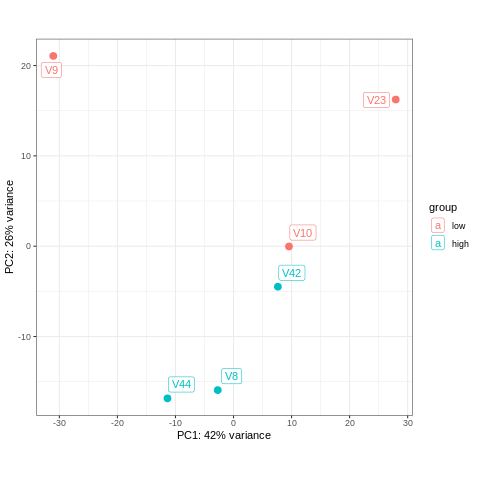

In [ ]:
%%R
# Apply Variance Stabilizing Transformation (VST)
vsd <- vst(dds,blind=F)

sample <- colnames(vsd)

# Create PCA plot colored by "relative_BMI" group
plotPCA(vsd,intgroup="relative_BMI") + theme_bw() + theme(aspect.ratio = 1) + geom_label_repel(aes(label = sample),
                   box.padding = 0.35,
                   point.padding = 0.5,
                   segment.color = 'grey50')

using ntop=500 top features by variance


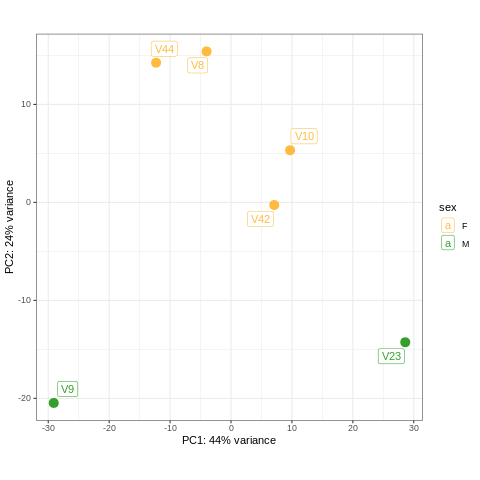

In [ ]:
%%R
# Create PCA plot colored by sex
pcaData <- plotPCA(vsd, intgroup="sex", returnData=TRUE)
percentVar <- round(100 * attr(pcaData, "percentVar"))

ggplot(pcaData, aes(PC1, PC2, color=sex, label=name)) +
  geom_point(size=4) +
  geom_label_repel(box.padding=0.35, point.padding=0.5, segment.color='grey50') +
  scale_color_manual(values=c("F"="#FFBB3F", "M"="#33A02C")) +
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) +
  theme_bw() + theme(aspect.ratio=1)


In [ ]:
%%R
# Surrogate Variable Analysis to correct for unknown batch effects

# Full model matrix including the variable of interest (relative_BMI)
mod  <- model.matrix(~relative_BMI, colData(dds))

# Null model matrix with intercept only, used as baseline for Surrogate Variable estimation
mod0 <- model.matrix(~1, colData(dds))

# Estimate the number of Surrogate Variables using "be" method
n.sv_be <- num.sv(assay(vsd), mod, method="be")
print(n.sv_be)

# Compute 2 SVs that capture hidden source of variation
svobj <- sva(assay(vsd), mod, mod0, n.sv = 2)

[1] 2
Number of significant surrogate variables is:  2 
Iteration (out of 5 ):1  2  3  4  5  

using ntop=500 top features by variance


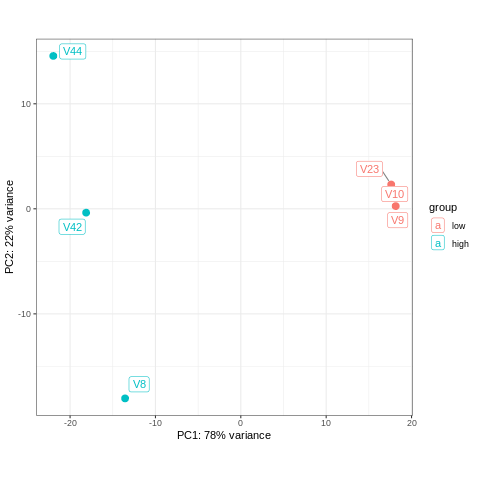

In [ ]:
%%R
vst_corrected <- removeBatchEffect(assay(vsd),
                                       batch = vsd$sex, # correct for known batch variable (sex)
                                       covariates = svobj$sv[,1:2], # correct for 2 SVs estimated by SVA
                                       design = mod)
vsd_sva <- vsd
assay(vsd_sva) <- vst_corrected

# Visualize PCA after batch correction
plotPCA(vsd_sva,intgroup="relative_BMI") + theme_bw() + theme(aspect.ratio = 1) + geom_label_repel(aes(label = sample),
                                                                                               box.padding = 0.35,
                                                                                               point.padding = 0.5,
                                                                                               segment.color = 'grey50')

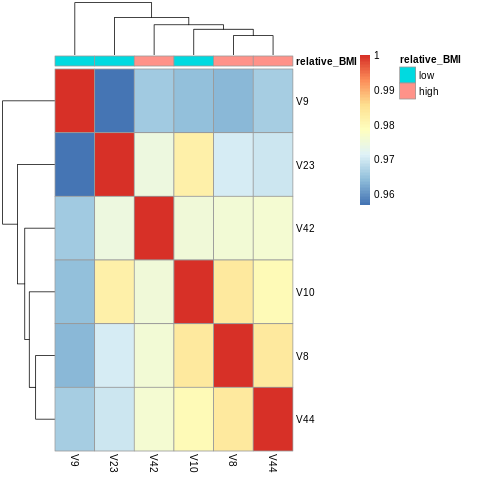

In [ ]:
%%R
# Heatmap
cor <- cor(assay(vsd)) # Calculate correlation between samples
annotation_col <- data.frame(relative_BMI = vsd$relative_BMI,row.names = colnames(cor))

# Plot Heatmap before batch correction
pheatmap(cor,annotation = annotation_col)

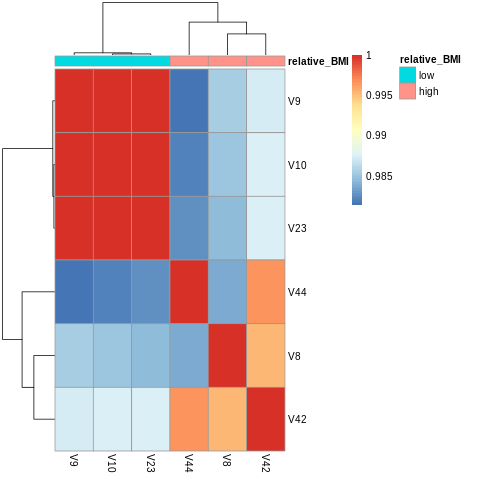

In [ ]:
%%R
# Heatmap
cor_sva <- cor(assay(vsd_sva))

# Plot Heatmap after batch correction
pheatmap(cor_sva,annotation = annotation_col)

In [ ]:
%%R
# Add 2 surrogate variables as new columns in the DESeq2 object's metadata
dds$sv1 <- svobj$sv[,1]
dds$sv2 <- svobj$sv[,2]

# Update design formula to inlcude :
# sex : known batch effect (confounding factor, confounding variables)
# sv1, sv2 : surrogate variables for unknown confounders
# relative_BMI : the main variable of interest (must be last)
design(dds) <- ~ sex + sv1 + sv2 + relative_BMI

# DESeq2 analysis
# Run DESeq2, differential expression analysis with the updated design
dds <- DESeq(dds,quiet = T)

# Print the names of all coefficients (results)
resultsNames(dds)

[1] "Intercept"                "sex_M_vs_F"               "sv1"                      "sv2"                      "relative_BMI_high_vs_low"


In [ ]:
%%R
# Extract differential expression analysis results : log2 fold change values are shrunk during process
# Shrink log2 fold changes to reduce noise from low-count genes
res <- lfcShrink(dds,coef="relative_BMI_high_vs_low")

# Calculate Wald statistic (stat value)
res$stat <- res$log2FoldChange / res$lfcSE
res_df <- as.data.frame(res)

# Cont the number of statistically significant differentially expressed genes (DEGs)
# Criteria : adjusted p-value < 0.05 & |log2FC| > 1
res_df %>% dplyr::filter(padj < 0.05 & abs(log2FoldChange) > 1) %>% nrow()

[1] 218


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


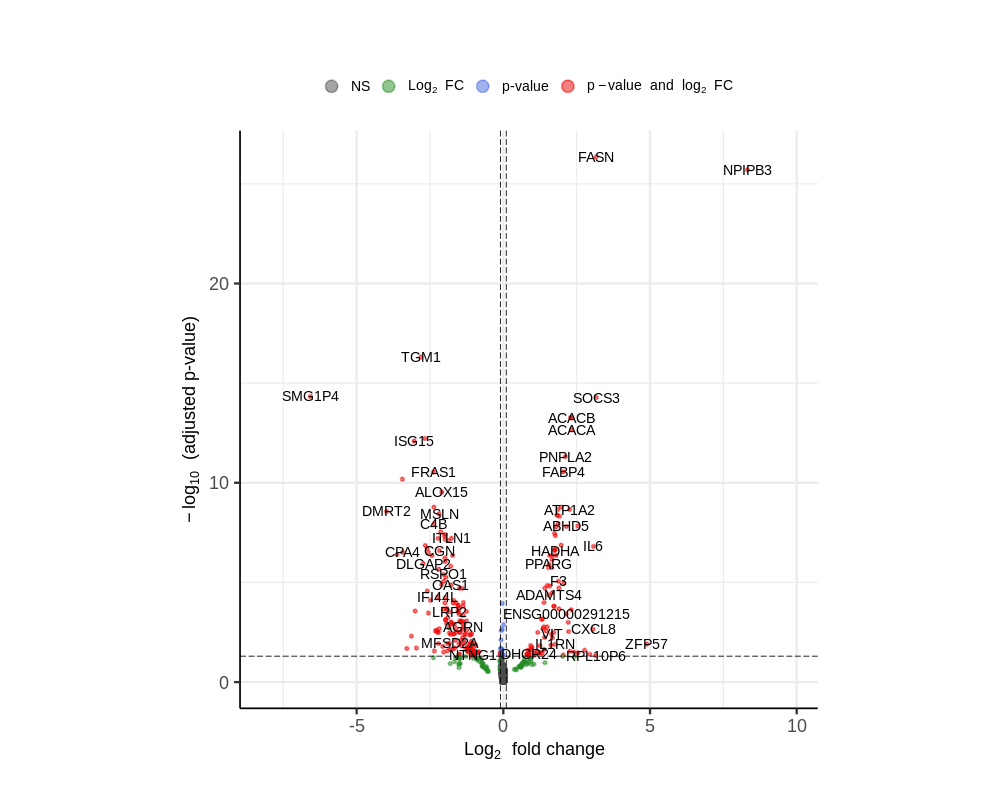

In [ ]:
%%R -w 1000 -h 800


# Draw Volcano plot to visualize differential expression results
EnhancedVolcano(res,
                x = "log2FoldChange",
                y = "padj",
                lab = rownames(res),
                pCutoff = 0.05,
                FCcutoff = 0.1,
                title = "",
                subtitle = "",
                caption = "",
                drawConnectors = F,
                ylab = expression(-log[10]~"(adjusted p-value)"),
                labSize = 5,
                pointSize = 1) +
  ylim(c(0, max(-log10(res$padj), na.rm = TRUE))) +
  theme(aspect.ratio = 1) +
  theme(text = element_text(family = "Arial"),
        legend.text = element_text(family = "Arial"))

In [ ]:
%%R
# Count the number of DEGs significantly upregulated in High group
res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange > 1) %>% nrow()

[1] 78


In [ ]:
%%R
options(width = 200)

# Top 10 DEGs significantly upregulated in High group, sorted by stat value
res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange > 1) %>% arrange(desc(stat)) %>% head(10)

            baseMean log2FoldChange     lfcSE       pvalue         padj      stat
NPIPB3     1381.0718       8.351164 0.7299591 9.852272e-31 1.513309e-26 11.440591
ATP1A2    27377.1567       2.241447 0.3497767 2.456315e-12 3.772899e-09  6.408223
HLA-DRB5   5925.5051       2.506114 0.4131015 2.673601e-11 2.933322e-08  6.066582
CCND1     13718.2105       1.946952 0.3429356 3.223776e-10 2.250782e-07  5.677310
FASN     130623.4643       1.534117 0.2886437 3.574160e-09 1.663609e-06  5.314917
ADAMTS4    3039.6339       1.663300 0.3392973 2.561820e-08 1.008963e-05  4.902189
RORB        828.6611       2.075546 0.4305209 2.976193e-08 1.142858e-05  4.821010
SOX18      1781.8498       1.705376 0.3663477 7.374713e-08 2.574445e-05  4.655075
HMCN2      1365.3210       1.744313 0.4158097 6.892703e-07 1.794439e-04  4.194980
SGK2       1283.5750       1.880191 0.4706177 1.325576e-06 3.084977e-04  3.995155


In [ ]:
%%R
# Count the number of DEGs significantly upregulated in Low group
res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange < -1) %>% nrow()

[1] 140


In [ ]:
%%R
options(width = 200)

# Top 10 DEGs upregulated in Low group, sorted by |stat| value
res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange < -1) %>% arrange(stat) %>% head(10)

        baseMean log2FoldChange     lfcSE       pvalue         padj      stat
TGM1   4111.2220      -2.785162 0.3059178 1.069485e-20 8.213643e-17 -9.104282
IFI6   2304.7036      -2.667025 0.3375683 3.058408e-16 1.174429e-12 -7.900696
ISG15   953.0578      -3.017685 0.3847708 5.277530e-16 1.621257e-12 -7.842812
FRAS1  2847.4257      -2.379020 0.3230217 1.937278e-14 4.959432e-11 -7.364892
COMP    525.2455      -3.402469 0.4731299 7.479646e-14 1.641248e-10 -7.191404
ALOX15 5534.0965      -2.048620 0.2984557 5.803857e-13 1.114341e-09 -6.864065
MX1    3169.1539      -2.337629 0.3495056 2.060490e-12 3.516570e-09 -6.688389
DMRT2   270.1595      -3.923575 0.5917338 4.650352e-12 5.952450e-09 -6.630641
MSLN   6340.5836      -2.189081 0.3326093 4.210696e-12 5.879662e-09 -6.581539
C4B    1284.7908      -2.408913 0.3697909 6.840778e-12 8.082642e-09 -6.514256


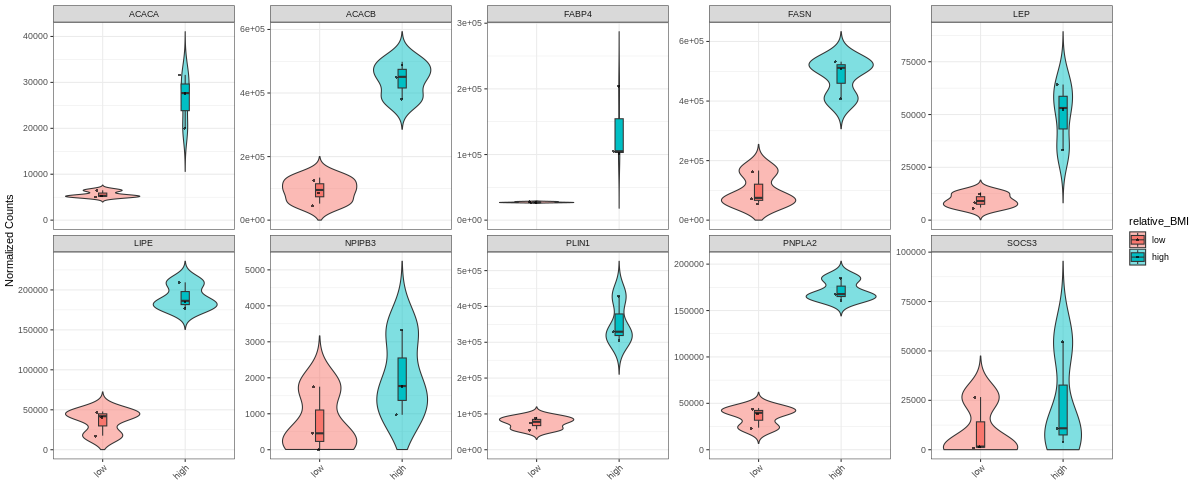

In [ ]:
%%R -w 1200 -h 500

# Sanity check : visually verify that top DEGs show consistent expression differences across groups
# Inspect normalized counts per sample to confirm that DEGs are not false positives

# Count plot of Top 10 positive genes
res_df$gene <- rownames(res_df)

pos <- res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange > 1) %>% arrange(desc(stat)) %>% pull(gene)

plot_data_pos <- lapply(pos[1:10], function(g) {
  d <- plotCounts(dds, gene = g, intgroup = "relative_BMI", returnData = TRUE)
  d$gene_name <- g
  return(d)
}) %>% bind_rows()

ggplot(plot_data_pos, aes(x = relative_BMI, y = count, fill = relative_BMI)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  geom_jitter(shape = 16, position = position_jitter(width = 0.1), size = 1, alpha = 0.7) +
  facet_wrap(~ gene_name, scales = "free_y", ncol = 5) +
  scale_y_continuous(limits = c(0, NA)) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(y = "Normalized Counts", x = "")

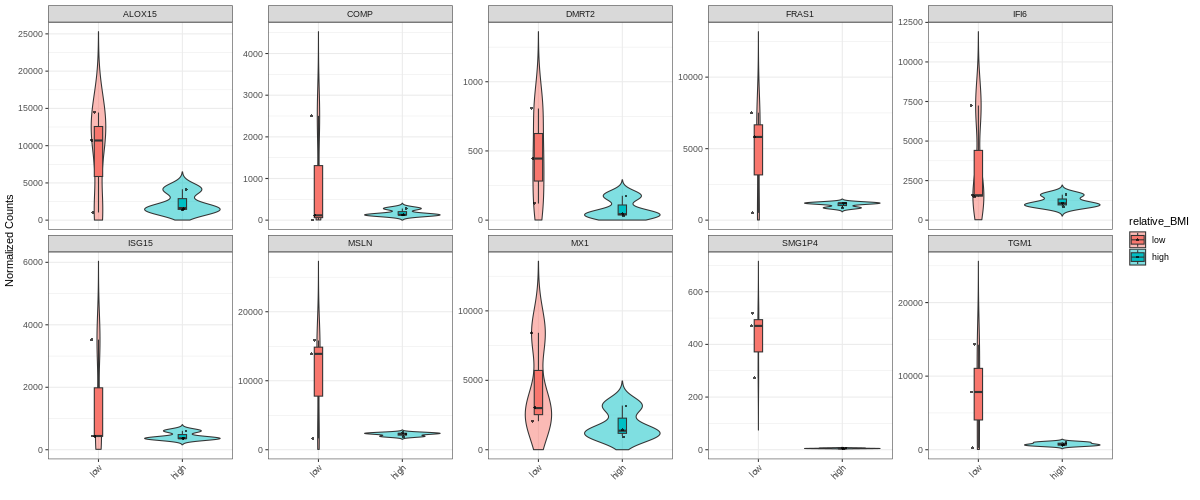

In [ ]:
%%R -w 1200 -h 500
# Count plot of top 10 negative genes
neg <- res_df %>% dplyr::filter(padj < 0.05 & log2FoldChange < -1) %>% arrange(stat) %>% pull(gene)

plot_data_neg <- lapply(neg[1:10], function(g) {
  d <- plotCounts(dds, gene = g, intgroup = "relative_BMI", returnData = TRUE)
  d$gene_name <- g
  return(d)
}) %>% bind_rows()

ggplot(plot_data_neg, aes(x = relative_BMI, y = count, fill = relative_BMI)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  geom_jitter(shape = 16, position = position_jitter(width = 0.1), size = 1, alpha = 0.7) +
  facet_wrap(~ gene_name, scales = "free_y", ncol = 5) +
  scale_y_continuous(limits = c(0, NA)) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(y = "Normalized Counts", x = "")

In [ ]:
%%R
# Create a ranked gene list based on the Wald Statistic (stat value) for Gene Sent Enrichment Analysis
# Genes at the top(positive value) are strongly upregulated; genes at the bottom are strongly downregulated
# This ranked list is the required input format for GSEA tools such as fgsea
ranks <- res_df %>% filter(!is.na(stat)) %>% arrange(desc(stat)) %>% pull(stat, name = gene)
head(ranks,20)


   NPIPB3      FASN     SOCS3     ACACB      LIPE     ACACA    PNPLA2     FABP4       LEP     PLIN1    ATP1A2       LPL      AKT2     FOXO1      RXRA     ACSL1  HLA-DRB5     ABHD5      IRS2     PLIN2 
11.358458 11.294865  8.325945  8.044577  8.032588  7.777616  7.402299  7.152762  6.521950  6.471036  6.440281  6.353168  6.339750  6.305935  6.161134  6.093653  6.080075  6.077132  5.961791  5.880729 


In [ ]:
%%R
# Load KEGG pathway gene sets form MSigDB database
kegg_sets <- msigdbr(species = "Homo sapiens", collection = "C2", subcollection = "CP:KEGG_LEGACY") %>% split(x = .$gene_symbol, f = .$gs_name)

# Preview the first 4 pathways and their member genes
head(kegg_sets,4)

$KEGG_ABC_TRANSPORTERS
 [1] "ABCA1"  "ABCA10" "ABCA12" "ABCA13" "ABCA2"  "ABCA3"  "ABCA4"  "ABCA5"  "ABCA6"  "ABCA7"  "ABCA8"  "ABCA9"  "ABCB1"  "ABCB10" "ABCB11" "ABCB4"  "ABCB5"  "ABCB6"  "ABCB7"  "ABCB8"  "ABCB9" 
[22] "ABCC1"  "ABCC10" "ABCC11" "ABCC12" "ABCC2"  "ABCC3"  "ABCC4"  "ABCC5"  "ABCC6"  "ABCC8"  "ABCC9"  "ABCD1"  "ABCD2"  "ABCD3"  "ABCD4"  "ABCG1"  "ABCG2"  "ABCG4"  "ABCG5"  "ABCG8"  "CFTR"  
[43] "TAP1"   "TAP2"  

$KEGG_ACUTE_MYELOID_LEUKEMIA
 [1] "AKT1"     "AKT2"     "AKT3"     "ARAF"     "BAD"      "BRAF"     "CCNA1"    "CCND1"    "CEBPA"    "CHUK"     "EIF4EBP1" "FLT3"     "GRB2"     "HRAS"     "IKBKB"    "IKBKG"    "JUP"     
[18] "KIT"      "KRAS"     "LEF1"     "MAP2K1"   "MAP2K2"   "MAPK1"    "MAPK3"    "MTOR"     "MYC"      "NFKB1"    "NRAS"     "PIK3CA"   "PIK3CB"   "PIK3CD"   "PIK3CG"   "PIK3R1"   "PIK3R2"  
[35] "PIK3R3"   "PIK3R5"   "PIM1"     "PIM2"     "PML"      "PPARD"    "RAF1"     "RARA"     "RELA"     "RPS6KB1"  "RPS6KB2"  "RUNX1"    "RUNX1T1"  "SOS

In [ ]:
%%R
# # Load GO:BP(Gene Ontology : Biological Process) gene sets form MSigDB database
gobp_sets <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "GO:BP") %>% split(x = .$gene_symbol, f = .$gs_name)

# Preivew the first 4 pathways and their member genes
head(gobp_sets,4)

$GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS
[1] "AASDHPPT" "ALDH1L1"  "ALDH1L2"  "MTHFD1"   "MTHFD1L"  "MTHFD2L" 

$GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS
 [1] "AADAT"  "ADHFE1" "COL6A1" "D2HGDH" "DLD"    "DLST"   "GOT1"   "GOT2"   "GPT2"   "IDH1"   "IDH2"   "KGD4"   "KYAT3"  "L2HGDH" "OGDH"   "OGDHL"  "PHYH"   "TAT"   

$GOBP_2FE_2S_CLUSTER_ASSEMBLY
 [1] "BOLA2"   "BOLA2B"  "FDX2"    "FXN"     "GLRX3"   "GLRX5"   "HSCB"    "ISCU"    "LYRM4"   "NDUFAB1" "NFS1"   

$GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION
 [1] "CPEB3"   "DHX36"   "DND1"    "HNRNPD"  "KHSRP"   "MOV10"   "PLEKHN1" "PUM1"    "PUM2"    "RBM24"   "RC3H1"   "TARDBP"  "TRIM71"  "UPF1"    "ZC3H12A" "ZC3H12D" "ZFP36"   "ZFP36L1" "ZFP36L2"



In [ ]:
%%R
# Run fgsea (Fast Gene Set Enrichment Analysis)

# Ensure reproducibility for results across runs
set.seed(123)

# Run GSEA against KEGG pathways
fgsea_kegg <- fgsea(pathways = kegg_sets, stats = ranks, minSize = 15, maxSize = 500)

# Rung GSEA against GO:BP gene sets
fgsea_gobp <- fgsea(pathways = gobp_sets, stats = ranks, minSize = 15, maxSize = 500)

In [ ]:
%%R
# Filter and display significantly enrihced pathways / gene sets
# Sorted by NES (Normalized Enrichment Score)
fgsea_kegg %>% filter(padj < 0.05) %>% arrange(desc(NES))
fgsea_gobp %>% filter(padj < 0.05) %>% arrange(desc(NES))

                                                  pathway         pval         padj   log2err         ES       NES  size                                 leadingEdge
                                                   <char>        <num>        <num>     <num>      <num>     <num> <int>                                      <list>
  1:                GOBP_REGULATION_OF_LIPID_LOCALIZATION 2.615407e-12 7.569589e-09 0.8986712  0.8625473  2.276844   146      ACACB,PNPLA2,LEP,LPL,AKT2,RXRA,...[28]
  2:                                GOBP_NUTRIENT_STORAGE 5.572372e-08 2.742303e-05 0.7195128  0.8703587  2.215091    87    ACACB,PNPLA2,LEP,LPL,ABHD5,PLIN2,...[25]
  3:       GOBP_NEGATIVE_REGULATION_OF_LIPID_LOCALIZATION 1.146499e-07 3.761474e-05 0.7049757  0.9253370  2.213760    44      PNPLA2,LEP,AKT2,ABHD5,IRS2,IL6,...[12]
  4:                GOBP_FATTY_ACYL_COA_METABOLIC_PROCESS 8.291158e-07 1.255473e-04 0.6594444  0.9223870  2.193052    40         FASN,ACACA,ACSL1,DGAT1,ACSL4,ELOVL6
  5:      

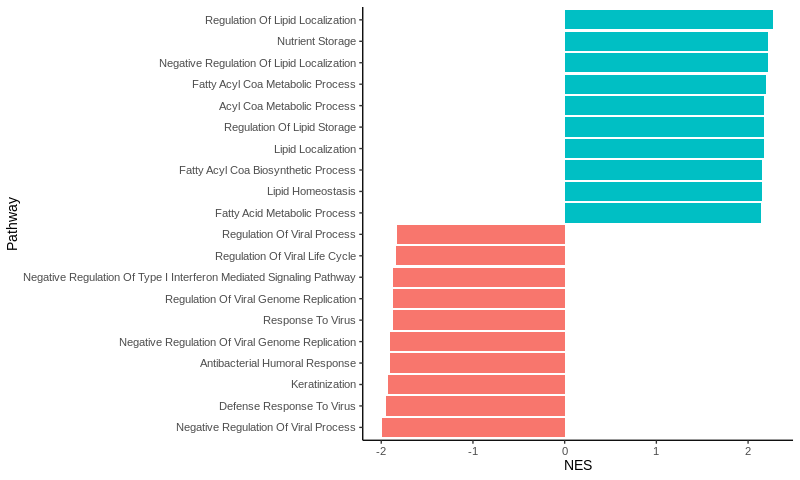

In [ ]:
%%R -w 800

# Visualize significant GSEA results using bar plot

plot_fgsea <- function(res) {
  tidy <- res %>% as_tibble() %>% filter(padj < 0.05) %>%
    mutate(pw = str_to_title(gsub("_", " ", gsub("^GOBP_|^KEGG_", "", pathway)))) %>%
    group_by(sign(NES)) %>% slice_max(abs(NES), n = 10) %>% ungroup()

  ggplot(tidy, aes(fct_reorder(pw, NES), NES, fill = NES > 0)) +
    geom_col() +
    scale_fill_manual(values = c("TRUE"="#00BFC4","FALSE"="#F8766D"), guide="none") +
    coord_flip() + labs(x="Pathway", y="NES") +
    theme_bw(base_size=14) +
    theme(panel.grid=element_blank(), panel.border=element_blank(), axis.line=element_line())
}

# Plot bar plot (GO:BP result)
plot_fgsea(fgsea_gobp)

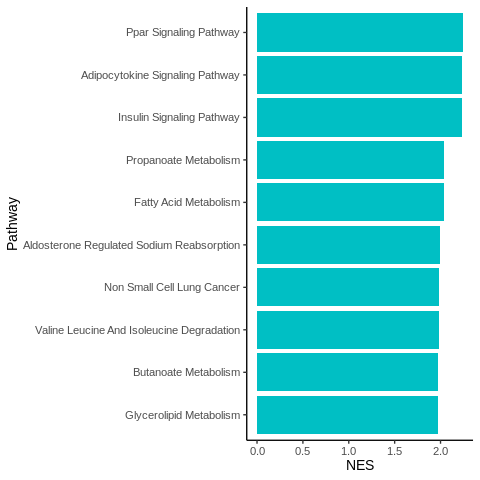

In [ ]:
%%R

# Plot bar plot (KEGG result)
plot_fgsea(fgsea_kegg)

In [ ]:
%%R
# plot KEGG leading edge gene heatmap of Insulin signaling pathway
leading_edge_genes <-  fgsea_kegg_df %>% filter(pathway == "KEGG_INSULIN_SIGNALING_PATHWAY") %>% pull(leadingEdge) %>% unlist()

mat <- log1p(count_matrix[intersect(leading_edge_genes, rownames(count_matrix)), ])

col_order <- c(high_samples, setdiff(colnames(mat), high_samples))

mat <- mat[, col_order]

annotation <- data.frame(Group = ifelse(colnames(mat) %in% high_samples, "High", "Low"),
                   row.names = colnames(mat))

pheatmap(mat, scale = "row", show_colnames = TRUE, show_rownames = TRUE,annotation = annotation,cluster_cols = F)

Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'fgsea_kegg_df' not found


RInterpreterError: Failed to parse and evaluate line '# kegg leading edge gene heatmap\nleading_edge_genes <-  fgsea_kegg_df %>% filter(pathway == "KEGG_INSULIN_SIGNALING_PATHWAY") %>% pull(leadingEdge) %>% unlist()\n\nmat <- log1p(count_matrix[intersect(leading_edge_genes, rownames(count_matrix)), ])\n\ncol_order <- c(high_samples, setdiff(colnames(mat), high_samples))\n\nmat <- mat[, col_order]\n\nannotation <- data.frame(Group = ifelse(colnames(mat) %in% high_samples, "High", "Low"),\n                   row.names = colnames(mat))\n\npheatmap(mat, scale = "row", show_colnames = TRUE, show_rownames = TRUE,annotation = annotation,cluster_cols = F)\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'fgsea_kegg_df' not found"

In [ ]:
%%R
# plot GO:BP leading edge gene heatmap of regulation of lipid localization gene set

leading_edge_genes <-  fgsea_gobp_df %>% filter(pathway == "GOBP_REGULATION_OF_LIPID_LOCALIZATION") %>% pull(leadingEdge) %>% unlist()

mat <- log1p(count_matrix[intersect(leading_edge_genes, rownames(count_matrix)), ])

col_order <- c(high_samples, setdiff(colnames(mat), high_samples))

mat <- mat[, col_order]

annotation <- data.frame(Group = ifelse(colnames(mat) %in% high_samples, "High", "Low"),
                         row.names = colnames(mat))

pheatmap(mat, scale = "row", show_colnames = TRUE, show_rownames = TRUE,annotation = annotation,cluster_cols = F)

In [ ]:
%%R

In [ ]:
%%R

In [ ]:
https://drive.google.com/file/d/1qMIv1l2siGtu7a_9cFBQmUAjPo9_P1Ct/view?usp=sharing
https://drive.google.com/file/d/1qMIv1l2siGtu7a_9cFBQmUAjPo9_P1Ct/view?usp=sharing

In [ ]:
!pwd

In [ ]:
import gdown

file_id = "1qMIv1l2siGtu7a_9cFBQmUAjPo9_P1Ct"
output = "/content/drive/MyDrive/packageset.zip" # 저장 위치 및 저장할 파일 이름
gdown.download(id=file_id, output=output, quiet=False)

FileNotFoundError: [Errno 2] No such file or directory: 'data'

In [ ]:
!tar -cvf /content/drive/MyDrive/Rib_test.tar /content/drive/MyDrive/R_libs

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
tar: /content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cov_bones.hpp: file changed as we read it
/content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cov_meat.hpp
tar: /content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cov_meat.hpp: file changed as we read it
/content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumprod_bones.hpp
tar: /content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumprod_bones.hpp: file changed as we read it
/content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumprod_meat.hpp
tar: /content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumprod_meat.hpp: file changed as we read it
/content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumsum_bones.hpp
tar: /content/drive/MyDrive/R_libs/RcppArmadillo/include/legacy/armadillo_bits/op_cumsum_

In [ ]:
!tar -cvf /content/drive/MyDrive/data.tar/ /content/drive/MyDrive/data

In [ ]:
!tar -xvf packageset.tar

In [ ]:
%%R
.libPaths("/content/drive/MyDrive/MOFA_test/R_libs")
.libPaths()

In [ ]:
%%R
.libPaths("/content/drive/MyDrive/MOFA_test/R_libs")

library(dplyr)
library(DESeq2)
library(ggplot2)

In [ ]:
!tar -cvf /content/drive/MyDrive/data.tar /content/drive/MyDrive/data

In [ ]:
import gdown

file_id = ""
output = "/content/drive/MyDrive/data.tar" # 저장 위치 및 저장할 파일 이름
gdown.download(id=file_id, output=output, quiet=False)

In [ ]:
!tar -xvf data.tar